# Sensitivity analysis — Dynamic Asset Allocation under AI-Concentration Risk

Companion to `AI_Concentration_Dynamic_Allocation.ipynb`. Every headline conclusion of the
main notebook rests on a handful of **subjective choices** (the assignment asks us to make
them explicit and defend them). Here we re-run the full rolling backtest while varying one
choice at a time:

1. **Estimation window**: 36 vs 60 vs 84 months (evaluated on a common out-of-sample period)
2. **Covariance treatment**: sample vs Ledoit-Wolf shrinkage
3. **Weight cap**: 20% vs 30% vs uncapped
4. **Rebalancing frequency**: monthly vs quarterly
5. **Black-Litterman calibration**: `tau` × view-magnitude grid (required by the assignment
   for the BL track)
6. **AI-bucket budget constraint** (max 25% in the AI/Tech cluster) as the *direct*
   alternative to managing concentration through robust estimation

Data are loaded from the frozen parquet cache produced by the main notebook, so both
notebooks analyse exactly the same panel. Michaud uses `B = 150` Monte Carlo paths here
(vs 300 in the main notebook): sensitivity analysis needs the *direction* of effects, not
the last decimal, and this keeps total runtime manageable.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

CACHE_DIR = Path('data/cache')
FIG_DIR = Path('figures')

# Same universe as the main notebook
tickers = ['SPY', 'IWM', 'EFA', 'EEM', 'QQQ', 'SMH', 'XLK', 'EWT', 'EWY',
           'SHY', 'IEF', 'TLT', 'TIP', 'LQD', 'HYG', 'GLD', 'DBC', 'VNQ', 'BIL']
asset_class = {
    'SPY': 'Equity_Broad', 'IWM': 'Equity_Broad', 'EFA': 'Equity_Broad', 'EEM': 'Equity_Broad',
    'QQQ': 'Equity_AI_Tech', 'SMH': 'Equity_AI_Tech', 'XLK': 'Equity_AI_Tech',
    'EWT': 'Equity_AI_Tech', 'EWY': 'Equity_AI_Tech',
    'SHY': 'Govt_Bonds', 'IEF': 'Govt_Bonds', 'TLT': 'Govt_Bonds', 'TIP': 'Govt_Bonds',
    'LQD': 'Credit', 'HYG': 'Credit',
    'GLD': 'Real_Assets', 'DBC': 'Real_Assets', 'VNQ': 'Real_Assets',
    'BIL': 'Cash',
}
bucket_members = {b: [t for t in tickers if asset_class[t] == b] for b in sorted(set(asset_class.values()))}
ai_cols = bucket_members['Equity_AI_Tech']
n = len(tickers)

prices_daily = pd.read_parquet(CACHE_DIR / 'prices_daily.parquet')[tickers]
first_valid = prices_daily.apply(lambda s: s.first_valid_index())
prices_daily = prices_daily.loc[first_valid.max():].dropna()

monthly_prices = prices_daily.resample('ME').last()
rets_m = np.log(monthly_prices / monthly_prices.shift(1)).dropna()
MONTHS_PER_YEAR = 12
T = len(rets_m)
rf_monthly = rets_m['BIL']
print(f'Panel loaded from cache: {T} monthly observations, {rets_m.index.min().date()} -> {rets_m.index.max().date()}')

Panel loaded from cache: 191 monthly observations, 2010-08-31 -> 2026-06-30


## 0. Parametrized engine

The same estimation / optimization / rolling-backtest machinery of the main notebook,
with every subjective choice exposed as a parameter. `start_idx` fixes the first
rebalance index so that configurations with different estimation windows can be compared
on an **identical out-of-sample period**.

In [2]:
def estimate_mu_sigma(window_rets, method='lw'):
    mu_hat = window_rets.mean().values * MONTHS_PER_YEAR
    if method == 'sample':
        Sigma_hat = window_rets.cov().values * MONTHS_PER_YEAR
    else:
        Sigma_hat = LedoitWolf().fit(window_rets.values).covariance_ * MONTHS_PER_YEAR
    return mu_hat, Sigma_hat

def neg_sharpe(w, mu_v, S):
    return -(w @ mu_v) / np.sqrt(w @ S @ w)

def max_sharpe_weights(mu_v, S, w_cap=0.30, extra_cons=None):
    n_ = len(mu_v)
    w0 = np.ones(n_) / n_
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    if extra_cons:
        cons += extra_cons
    res = minimize(neg_sharpe, w0, args=(mu_v, S), method='SLSQP',
                   bounds=[(0.0, w_cap)] * n_, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else np.ones(n_) / n_

def michaud_weights(mu_hat, Sigma_hat, B=150, T_sim=60, w_cap=0.30):
    mu_m, S_m = mu_hat / 12, Sigma_hat / 12
    W_sim = np.zeros((B, n))
    for b in range(B):
        sim = np.random.multivariate_normal(mu_m, S_m, size=T_sim)
        W_sim[b] = max_sharpe_weights(sim.mean(axis=0) * 12, np.cov(sim.T) * 12, w_cap=w_cap)
    w = W_sim.mean(axis=0)
    return w / w.sum()

# Black-Litterman pieces (identical to the main notebook)
w_eq_bucket = {'Equity_Broad': 0.35, 'Equity_AI_Tech': 0.15, 'Govt_Bonds': 0.25,
               'Credit': 0.10, 'Real_Assets': 0.10, 'Cash': 0.05}
w_eq = np.array([w_eq_bucket[asset_class[t]] / len(bucket_members[asset_class[t]]) for t in tickers])

def relative_view_row(long_names, short_names):
    row = np.zeros(n)
    for t in long_names:
        row[tickers.index(t)] = 1.0 / len(long_names)
    for t in short_names:
        row[tickers.index(t)] = -1.0 / len(short_names)
    return row

P_BASE = np.vstack([
    relative_view_row(ai_cols, bucket_members['Equity_Broad']),
    relative_view_row(['EWY', 'EWT'], ['QQQ', 'SMH', 'XLK']),
    relative_view_row(['SHY'], ['TLT']),
])
Q_BASE = np.array([-0.02, -0.03, 0.01])

def bl_weights(mu_hat, Sigma_hat, tau=0.03, q_scale=1.0, delta=2.5, w_cap=0.30):
    inv = np.linalg.inv
    P, Q = P_BASE, Q_BASE * q_scale
    Omega = np.diag(np.diag(P @ (tau * Sigma_hat) @ P.T))
    Pi = delta * Sigma_hat @ w_eq
    M = inv(inv(tau * Sigma_hat) + P.T @ inv(Omega) @ P)
    mu_BL = M @ (inv(tau * Sigma_hat) @ Pi + P.T @ inv(Omega) @ Q)
    return max_sharpe_weights(mu_BL, Sigma_hat + M, w_cap=w_cap)

def run_backtest(strategy_fn, window=60, rebal=1, cov='lw', start_idx=None, **kwargs):
    '''Rolling walk-forward backtest; returns (weights history, monthly returns).'''
    start = max(window, start_idx or 0)
    rebalance_idx = list(range(start, T, rebal))
    rebalance_dates = rets_m.index[rebalance_idx]
    W_hist = pd.DataFrame(index=rebalance_dates, columns=tickers, dtype=float)
    port_rets = pd.Series(index=rets_m.index, dtype=float)
    for j, t_idx in enumerate(rebalance_idx):
        mu_hat, Sigma_hat = estimate_mu_sigma(rets_m.iloc[t_idx - window: t_idx], method=cov)
        w = strategy_fn(mu_hat, Sigma_hat, **kwargs)
        W_hist.iloc[j] = w
        end = rebalance_idx[j + 1] if j + 1 < len(rebalance_idx) else T
        for k in range(t_idx, end):
            port_rets.iloc[k] = rets_m.iloc[k].values @ w
    return W_hist, port_rets.dropna()

def metrics(ret, W_hist, label):
    rf = rf_monthly.loc[ret.index]
    ann_ret, ann_rf = ret.mean() * 12, rf.mean() * 12
    ann_vol = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    jun = ret.loc['2026-06-01':'2026-06-30']
    feb = ret.loc['2026-02-01':'2026-02-28']
    return pd.Series({
        'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
        'Sharpe': (ann_ret - ann_rf) / ann_vol, 'Max Drawdown': max_dd,
        'Feb 2026': (1 + feb).prod() - 1 if len(feb) else np.nan,
        'Jun 2026': (1 + jun).prod() - 1 if len(jun) else np.nan,
        'Avg AI weight': W_hist[ai_cols].sum(axis=1).mean(),
        'Avg HHI': (W_hist ** 2).sum(axis=1).mean(),
        'Avg Turnover': W_hist.diff().abs().sum(axis=1).mean(),
    }, name=label)

fmt = {'Ann. Return': '{:+.2%}', 'Ann. Vol': '{:.2%}', 'Sharpe': '{:.3f}',
       'Max Drawdown': '{:+.2%}', 'Feb 2026': '{:+.2%}', 'Jun 2026': '{:+.2%}',
       'Avg AI weight': '{:.2%}', 'Avg HHI': '{:.3f}', 'Avg Turnover': '{:.3f}'}
print('Engine ready.')

Engine ready.


## 1. Estimation window: 36 vs 60 vs 84 months

All configurations are evaluated from the same first rebalance (`start_idx = 84`), i.e. on
an identical out-of-sample period, so differences come only from the estimation window.

In [3]:
rows = []
for W in [36, 60, 84]:
    np.random.seed(42)
    Wm, rm = run_backtest(max_sharpe_weights, window=W, start_idx=84)
    rows.append(metrics(rm, Wm, f'Markowitz, {W}m'))
    np.random.seed(42)
    Wc, rc = run_backtest(michaud_weights, window=W, start_idx=84, T_sim=W)
    rows.append(metrics(rc, Wc, f'Michaud, {W}m'))
    Wb, rb = run_backtest(bl_weights, window=W, start_idx=84)
    rows.append(metrics(rb, Wb, f'Black-Litterman, {W}m'))

grid_window = pd.DataFrame(rows)
grid_window.round(4).to_csv(FIG_DIR / 'sens_estimation_window.csv')
grid_window.style.format(fmt)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Feb 2026,Jun 2026,Avg AI weight,Avg HHI,Avg Turnover
"Markowitz, 36m",+5.38%,8.03%,0.370,-23.39%,+1.89%,-3.99%,22.21%,0.189,0.223
"Michaud, 36m",+5.56%,6.89%,0.457,-18.92%,+1.79%,-3.41%,16.80%,0.125,0.152
"Black-Litterman, 36m",+7.00%,11.89%,0.386,-20.03%,+0.12%,+0.25%,0.01%,0.193,0.091
"Markowitz, 60m",+7.83%,7.26%,0.747,-17.23%,+2.36%,-4.57%,24.89%,0.180,0.149
"Michaud, 60m",+7.03%,6.71%,0.689,-17.07%,+2.24%,-3.97%,19.83%,0.127,0.133
"Black-Litterman, 60m",+7.86%,12.28%,0.443,-21.24%,+0.55%,-0.07%,0.00%,0.196,0.066
"Markowitz, 84m",+8.20%,7.34%,0.790,-17.36%,+2.14%,-2.81%,23.69%,0.193,0.110
"Michaud, 84m",+7.61%,7.08%,0.734,-17.36%,+2.27%,-2.88%,20.79%,0.136,0.120
"Black-Litterman, 84m",+8.08%,12.37%,0.459,-21.01%,+0.87%,-0.25%,0.00%,0.197,0.056


## 2. Covariance treatment: sample vs Ledoit-Wolf

With 60 monthly observations and 19 assets, the sample covariance is nearly
ill-conditioned; shrinkage should stabilize Markowitz in particular.

In [4]:
rows = []
for cov in ['sample', 'lw']:
    np.random.seed(42)
    Wm, rm = run_backtest(max_sharpe_weights, cov=cov)
    rows.append(metrics(rm, Wm, f'Markowitz, {cov}'))
    np.random.seed(42)
    Wc, rc = run_backtest(michaud_weights, cov=cov)
    rows.append(metrics(rc, Wc, f'Michaud, {cov}'))

grid_cov = pd.DataFrame(rows)
grid_cov.round(4).to_csv(FIG_DIR / 'sens_covariance.csv')
grid_cov.style.format(fmt)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Feb 2026,Jun 2026,Avg AI weight,Avg HHI,Avg Turnover
"Markowitz, sample",+5.16%,4.06%,0.778,-9.19%,+1.83%,-3.40%,10.32%,0.239,0.098
"Michaud, sample",+5.06%,4.16%,0.737,-9.64%,+1.90%,-3.20%,11.34%,0.203,0.090
"Markowitz, lw",+7.67%,7.11%,0.797,-17.23%,+2.36%,-4.57%,24.53%,0.185,0.147
"Michaud, lw",+6.90%,6.44%,0.761,-16.95%,+2.29%,-3.90%,19.79%,0.123,0.141


## 3. Weight cap: 20% vs 30% vs uncapped

The cap is itself a (blunt) concentration-management device: how much of the
"robustness" of each strategy is actually the cap doing the work?

In [5]:
rows = []
for cap in [0.20, 0.30, 1.00]:
    lbl = 'uncapped' if cap == 1.0 else f'{cap:.0%} cap'
    np.random.seed(42)
    Wm, rm = run_backtest(max_sharpe_weights, w_cap=cap)
    rows.append(metrics(rm, Wm, f'Markowitz, {lbl}'))
    Wb, rb = run_backtest(bl_weights, w_cap=cap)
    rows.append(metrics(rb, Wb, f'Black-Litterman, {lbl}'))

grid_cap = pd.DataFrame(rows)
grid_cap.round(4).to_csv(FIG_DIR / 'sens_weight_cap.csv')
grid_cap.style.format(fmt)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Feb 2026,Jun 2026,Avg AI weight,Avg HHI,Avg Turnover
"Markowitz, 20% cap",+8.03%,7.09%,0.850,-17.62%,+1.95%,-4.37%,25.31%,0.159,0.128
"Black-Litterman, 20% cap",+6.74%,9.81%,0.483,-20.10%,+0.62%,-0.06%,0.00%,0.161,0.049
"Markowitz, 30% cap",+7.67%,7.11%,0.797,-17.23%,+2.36%,-4.57%,24.53%,0.185,0.147
"Black-Litterman, 30% cap",+7.65%,11.60%,0.487,-21.24%,+0.55%,-0.07%,0.00%,0.195,0.068
"Markowitz, uncapped",+7.28%,6.86%,0.769,-17.23%,+2.02%,-3.78%,23.85%,0.214,0.151
"Black-Litterman, uncapped",+7.64%,12.24%,0.461,-21.24%,+0.55%,-0.07%,0.00%,0.215,0.074


## 4. Rebalancing frequency: monthly vs quarterly

Same estimation choices, one third of the trades: do the conclusions survive lower
turnover?

In [6]:
rows = []
for rb_ in [1, 3]:
    lbl = 'monthly' if rb_ == 1 else 'quarterly'
    np.random.seed(42)
    Wm, rm = run_backtest(max_sharpe_weights, rebal=rb_)
    rows.append(metrics(rm, Wm, f'Markowitz, {lbl}'))
    np.random.seed(42)
    Wc, rc = run_backtest(michaud_weights, rebal=rb_)
    rows.append(metrics(rc, Wc, f'Michaud, {lbl}'))
    Wb, rbl = run_backtest(bl_weights, rebal=rb_)
    rows.append(metrics(rbl, Wb, f'Black-Litterman, {lbl}'))

grid_rebal = pd.DataFrame(rows)
grid_rebal.round(4).to_csv(FIG_DIR / 'sens_rebalancing.csv')
grid_rebal.style.format(fmt)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Feb 2026,Jun 2026,Avg AI weight,Avg HHI,Avg Turnover
"Markowitz, monthly",+7.67%,7.11%,0.797,-17.23%,+2.36%,-4.57%,24.53%,0.185,0.147
"Michaud, monthly",+6.90%,6.44%,0.761,-16.95%,+2.29%,-3.90%,19.79%,0.123,0.141
"Black-Litterman, monthly",+7.65%,11.60%,0.487,-21.24%,+0.55%,-0.07%,0.00%,0.195,0.068
"Markowitz, quarterly",+7.87%,7.33%,0.800,-18.49%,+2.36%,-4.72%,24.53%,0.185,0.248
"Michaud, quarterly",+6.96%,6.58%,0.754,-17.52%,+2.26%,-4.16%,19.72%,0.124,0.174
"Black-Litterman, quarterly",+7.76%,11.49%,0.502,-21.82%,+0.55%,+0.16%,0.00%,0.195,0.122


## 5. Black-Litterman calibration: `tau` × view magnitude

The assignment explicitly requires documenting how the BL confidence is calibrated.
`q_scale` multiplies all three view magnitudes (0.5x = milder views, 2x = twice as
aggressive); `tau` controls how tight the equilibrium prior is. We report the full-sample
Sharpe and the June-2026 crisis-month return for each combination.

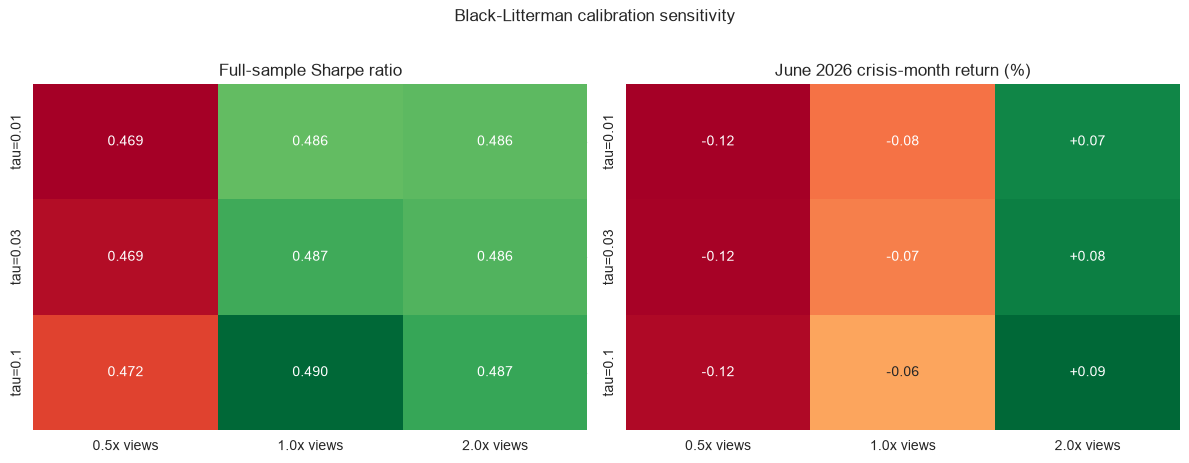

In [7]:
taus = [0.01, 0.03, 0.10]
scales = [0.5, 1.0, 2.0]
sharpe_grid = pd.DataFrame(index=[f'tau={t}' for t in taus], columns=[f'{s}x views' for s in scales], dtype=float)
jun_grid = sharpe_grid.copy()

for i, tau in enumerate(taus):
    for j, sc in enumerate(scales):
        Wb, rb = run_backtest(bl_weights, tau=tau, q_scale=sc)
        m = metrics(rb, Wb, '')
        sharpe_grid.iloc[i, j] = m['Sharpe']
        jun_grid.iloc[i, j] = m['Jun 2026']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(sharpe_grid.astype(float), annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0], cbar=False)
axes[0].set_title('Full-sample Sharpe ratio')
sns.heatmap(jun_grid.astype(float) * 100, annot=True, fmt='+.2f', cmap='RdYlGn', ax=axes[1], cbar=False)
axes[1].set_title('June 2026 crisis-month return (%)')
plt.suptitle('Black-Litterman calibration sensitivity', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sens_bl_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
sharpe_grid.round(4).to_csv(FIG_DIR / 'sens_bl_tau_sharpe.csv')

## 6. The direct alternative: an explicit AI-bucket budget constraint

Instead of *hoping* that resampling or views tame the AI exposure, we can simply
constrain the AI/Tech bucket to at most 25% of the portfolio inside the Markowitz
optimization, and compare.

In [8]:
ai_idx = [tickers.index(t) for t in ai_cols]
ai_budget_cons = [{'type': 'ineq', 'fun': lambda w: 0.25 - np.sum(w[ai_idx])}]

def markowitz_ai_budget(mu_hat, Sigma_hat):
    return max_sharpe_weights(mu_hat, Sigma_hat, extra_cons=ai_budget_cons)

rows = []
np.random.seed(42)
Wm, rm = run_backtest(max_sharpe_weights)
rows.append(metrics(rm, Wm, 'Markowitz (unconstrained AI)'))
Wa, ra = run_backtest(markowitz_ai_budget)
rows.append(metrics(ra, Wa, 'Markowitz + AI budget <= 25%'))
np.random.seed(42)
Wc, rc = run_backtest(michaud_weights)
rows.append(metrics(rc, Wc, 'Michaud'))
Wb, rb = run_backtest(bl_weights)
rows.append(metrics(rb, Wb, 'Black-Litterman'))

grid_budget = pd.DataFrame(rows)
grid_budget.round(4).to_csv(FIG_DIR / 'sens_ai_budget.csv')
grid_budget.style.format(fmt)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Feb 2026,Jun 2026,Avg AI weight,Avg HHI,Avg Turnover
Markowitz (unconstrained AI),+7.67%,7.11%,0.797,-17.23%,+2.36%,-4.57%,24.53%,0.185,0.147
Markowitz + AI budget <= 25%,+7.49%,6.71%,0.818,-16.78%,+2.36%,-4.57%,21.40%,0.184,0.139
Michaud,+6.90%,6.44%,0.761,-16.95%,+2.29%,-3.90%,19.79%,0.123,0.141
Black-Litterman,+7.65%,11.60%,0.487,-21.24%,+0.55%,-0.07%,0.00%,0.195,0.068


## 7. Reading the results

**1. Estimation window (common out-of-sample period, first rebalance at month 84).**
The 36-month window is clearly too noisy: Markowitz Sharpe collapses to 0.37 (vs 0.75 at
60m, 0.79 at 84m) and drawdowns deepen. Michaud's relative advantage is largest exactly
where estimation noise is worst (Sharpe 0.46 vs 0.37 at 36m) — consistent with resampling
being a fix for estimation error. The 60m baseline is defensible; 84m is marginally
smoother but slower to adapt.

**2. Covariance treatment.** Sample covariance and Ledoit–Wolf deliver similar Sharpe
(0.78 vs 0.80 for Markowitz) but *very* different portfolios: the sample-covariance
portfolio is far more timid (4.1% vol, 10% AI weight, higher HHI) because the
ill-conditioned matrix inflates apparent risk along some directions. Shrinkage is the
better-behaved baseline, as argued in the main notebook.

**3. Weight cap.** The cap does real work: tightening it to 20% *raises* Markowitz's
Sharpe to 0.85 (uncapped: 0.77) while cutting concentration. A blunt constraint is a
surprisingly strong competitor to sophisticated robustness — worth saying out loud in the
presentation.

**4. Rebalancing frequency.** Quarterly rebalancing changes essentially nothing
(Markowitz Sharpe 0.80, BL slightly *better* at 0.50) while trading far less often. The
headline conclusions survive lower turnover.

**5. Black–Litterman calibration.** The Sharpe grid is remarkably flat across
`tau` ∈ {0.01, 0.03, 0.10} and view magnitudes 0.5×–2× (0.47–0.49): the BL conclusions do
not hinge on a lucky calibration. Note that with these three cautionary views the
optimizer allocates essentially **zero to the AI cluster** throughout — BL here is a
deliberate insurance portfolio, which is exactly why it was flat in June 2026 and lagged
during the rally.

**6. The AI budget constraint — the punchline.** Capping the AI bucket at 25% slightly
*improves* Markowitz (Sharpe 0.82 vs 0.80) but leaves the June 2026 outcome **identical**
(−4.6%): constraining the AI theme did not protect in the AI crisis, because — as the main
notebook shows — the June damage came through the gold/commodities momentum positions hit
by the rate shock, not through the AI cluster. Concentration risk is a property of the
*estimation process*, not of any single theme you happen to be worried about.
